![Google Play Store Analysis](https://upload.wikimedia.org/wikipedia/commons/thumb/7/78/Google_Play_Store_badge_EN.svg/1280px-Google_Play_Store_badge_EN.svg.png)

# Google Play Store App Market Analysis
## Uncovering Trends in App Success for a New Market Entrant

## Overview
A startup preparing to launch its first Android application has commissioned this analysis to 
understand the competitive landscape of the Google Play Store. Using a dataset of over 10,000 
apps spanning multiple categories, pricing models, and content types, this project applies the 
CRISP-DM framework — from data loading and cleaning in PySpark, through to an interactive 
multi-page Tableau dashboard — to identify general trends in app success. Key areas of 
investigation include which categories attract the most installs, how pricing strategy affects 
user engagement, what rating patterns exist across genres, and what characteristics 
high-performing apps tend to share. The findings are designed to give the startup actionable, 
data-backed guidance as they plan their entry into the Android market.

### Lab Structure (CRISP-DM)
| Step | Phase | Description |
|------|-------|-------------|
| 1 | Data Acquisition | Load dataset using PySpark |
| 2 | Business Understanding | Define analytical questions |
| 3 | Data Understanding | Initial EDA with PySpark |
| 4 | Data Preparation | Clean data, export CSV for Tableau |
| 5 | Data Analysis | Visualizations addressing business questions |
| 6 | Dashboard Creation | Multi-page interactive Tableau dashboard |
| 7 | Documentation | Technical documentation |

## Business Understanding
- Set the stage for analysis
- Why are these findings relevant/important?
- Introduce stakeholders
- Postulate about questions you want to ask/answer

### Background
The mobile app market is one of the fastest growing digital industries, with the Google Play 
Store hosting over 3 million apps and generating billions in annual revenue. For a startup 
entering this space, understanding what drives app success is critical — the difference between 
a well-positioned app and a poorly positioned one can mean the difference between traction and 
obscurity.

### Stakeholders
| Stakeholder | Role | Interest in Analysis |
|-------------|------|----------------------|
| Startup Founders | Primary Decision Makers | Which category/market to enter |
| Product Team | App Development | What features and content ratings resonate |
| Marketing Team | Growth & Acquisition | What pricing strategy drives installs |
| Investors | Funding & ROI | Evidence of market opportunity |

### Why This Matters
Before writing a single line of code, the startup needs answers to strategic questions:
- Is it better to launch a free or paid app?
- Which categories are saturated vs. underserved?
- Do more reviews correlate with more installs?
- What content rating reaches the widest audience?
- Does app size affect user adoption?

### Analytical Questions
1. Which app categories have the highest average installs?
2. How does pricing (Free vs. Paid) affect ratings and installs?
3. What is the relationship between number of reviews and install count?
4. Which categories are most competitive (high volume of apps)?
5. What content ratings dominate the most successful apps?
6. Is there a relationship between app size and user rating?

## Data Understanding
- Present the source of data
- Describe the data available
- What is relevant to keep what is not
- Present any data cleaning that needs to happen
- Null values? Type mismatches? Duplicates?

### Data Source
The dataset is sourced from Kaggle's Google Play Store Apps dataset, containing information 
scraped from the Google Play Store. It contains **10,841 records** across **13 columns**, 
representing a broad cross-section of apps available on the platform.

### Data Dictionary
The dataset contains the following columns:

**App** is a string identifier for the app name and is low relevance — used for labeling only.<br>
**Category** is a string representing the broad app category (e.g. GAME, TOOLS) and is highly 
relevant as the primary grouping variable for trend analysis.<br>
**Rating** is a float representing the average user rating out of 5 and is a primary success metric.<br> **Reviews** is stored as a string but represents the number of user reviews — a key engagement indicator<br> 
**Size** is a string representing app size (e.g. 19M, 2.8M) and has medium relevance as a potential factor in user adoption. <br>
**Installs** is stored as a string (e.g. "10,000+") but represents download brackets — a primary success metric.<br>
**Type** indicates whether an app is Free or Paid and is highly relevant to pricing strategy analysis.<br>
**Price** is stored as a string with a dollar sign prefix and is relevant to pricing analysis.<br>
**Content Rating** describes the target audience age group and has medium relevance for understanding market reach. <br>
**Genres** provides more granular genre tags than Category and has medium relevance.<br>
**Last Updated** is a string date and serves as a signal for app maintenance activity.<br>
**Current Ver** and **Android Ver** are low relevance and will not be central to the analysis.

### Data Quality Issues Identified
Several data quality issues will need to be addressed in the preparation phase. The Reviews, 
Installs, and Price columns are all stored as strings and will need to be cast to numeric types. 
The Installs column specifically contains "+" and "," characters that must be stripped before 
conversion. The Size column uses mixed units (M and k) and will need to be standardized to MB, 
with "Varies with device" entries treated as null. Similarly, "Varies with device" appears in 
the Android Ver column and will also be nulled out. The Price column contains a dollar sign 
prefix that must be removed before casting to float. Additionally, the Rating, Size, and 
Android Ver columns likely contain missing values that will need to be investigated and handled 
appropriately. Finally, the full dataset will be checked for duplicate rows and dropped if found.

In [1]:
# Imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, FloatType, IntegerType, LongType
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings("ignore")


In [2]:
# EDA Code Here - Create New Cells As Needed
spark = SparkSession.builder.appName("GooglePlayStore").master('local[*]').getOrCreate()

df = spark.read.csv(
   "google_play_store_dataset.csv",
    header=True,
    inferSchema=False
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/06 16:04:24 WARN Utils: Your hostname, Miriam, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/06 16:04:24 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/06 16:04:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
#Shape and schema
df.printSchema()
print(f"Rows: {df.count()}")
print(f"Columns: {len(df.columns)}")

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: string (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)

Rows: 10841
Columns: 13


In [4]:
#Preview of the data
df.show(5, truncate=False)

+--------------------------------------------------+--------------+------+-------+----+-----------+----+-----+--------------+-------------------------+----------------+------------------+------------+
|App                                               |Category      |Rating|Reviews|Size|Installs   |Type|Price|Content Rating|Genres                   |Last Updated    |Current Ver       |Android Ver |
+--------------------------------------------------+--------------+------+-------+----+-----------+----+-----+--------------+-------------------------+----------------+------------------+------------+
|Photo Editor & Candy Camera & Grid & ScrapBook    |ART_AND_DESIGN|4.1   |159    |19M |10,000+    |Free|0    |Everyone      |Art & Design             |January 7, 2018 |1.0.0             |4.0.3 and up|
|Coloring book moana                               |ART_AND_DESIGN|3.9   |967    |14M |500,000+   |Free|0    |Everyone      |Art & Design;Pretend Play|January 15, 2018|2.0.0             |4.0.3 and

In [5]:
#Check for null values
from pyspark.sql.functions import col, sum as spark_sum, isnan, when

null_counts = df.select([
    spark_sum(when(col(c).isNull() | (col(c) == ""), 1).otherwise(0)).alias(c)
    for c in df.columns
])

null_counts.show(vertical=True)

-RECORD 0-------------
 App            | 0   
 Category       | 0   
 Rating         | 0   
 Reviews        | 0   
 Size           | 0   
 Installs       | 0   
 Type           | 0   
 Price          | 0   
 Content Rating | 1   
 Genres         | 0   
 Last Updated   | 0   
 Current Ver    | 1   
 Android Ver    | 1   



In [6]:
#Duplicate row count 
total = df.count()
distinct = df.distinct().count()
print(f"Total rows: {total}")
print(f"Distinct rows: {distinct}")
print(f"Duplicate rows: {total - distinct}")

Total rows: 10841
Distinct rows: 10358
Duplicate rows: 483


In [7]:
# Unique values
for c in df.columns:
    unique = df.select(c).distinct().count()
    print(f"{c}: {unique} unique values")

App: 9660 unique values
Category: 36 unique values
Rating: 43 unique values
Reviews: 6002 unique values
Size: 464 unique values
Installs: 24 unique values
Type: 6 unique values
Price: 95 unique values
Content Rating: 9 unique values
Genres: 121 unique values
Last Updated: 1379 unique values
Current Ver: 2836 unique values
Android Ver: 37 unique values


In [8]:
# Value distribution - category
df.groupBy("Category").count().orderBy("count", ascending=False).show(20)

+-------------------+-----+
|           Category|count|
+-------------------+-----+
|             FAMILY| 1972|
|               GAME| 1144|
|              TOOLS|  843|
|            MEDICAL|  463|
|           BUSINESS|  460|
|       PRODUCTIVITY|  424|
|    PERSONALIZATION|  392|
|      COMMUNICATION|  387|
|             SPORTS|  384|
|          LIFESTYLE|  382|
|            FINANCE|  366|
| HEALTH_AND_FITNESS|  340|
|        PHOTOGRAPHY|  335|
|             SOCIAL|  295|
| NEWS_AND_MAGAZINES|  283|
|           SHOPPING|  260|
|   TRAVEL_AND_LOCAL|  258|
|             DATING|  234|
|BOOKS_AND_REFERENCE|  231|
|      VIDEO_PLAYERS|  175|
+-------------------+-----+
only showing top 20 rows


In [9]:
#Value Distribution: Type & Content Rating
df.groupBy("Type").count().orderBy("count", ascending=False).show()
df.groupBy("Content Rating").count().orderBy("count", ascending=False).show()

+------+-----+
|  Type|count|
+------+-----+
|  Free|10037|
|  Paid|  800|
|     0|    1|
|102248|    1|
|   NaN|    1|
|  2509|    1|
+------+-----+

+---------------+-----+
| Content Rating|count|
+---------------+-----+
|       Everyone| 8713|
|           Teen| 1208|
|     Mature 17+|  498|
|   Everyone 10+|  414|
|Adults only 18+|    3|
|        Unrated|    2|
|     5,000,000+|    1|
|           NULL|    1|
|     1,000,000+|    1|
+---------------+-----+



In [10]:
# Check for messy values 
df.groupBy("Size").count().orderBy("count", ascending=False).show(10)
df.groupBy("Installs").count().orderBy("count", ascending=False).show(10)
df.groupBy("Price").count().orderBy("count", ascending=False).show(10)

+------------------+-----+
|              Size|count|
+------------------+-----+
|Varies with device| 1694|
|               11M|  198|
|               12M|  196|
|               14M|  194|
|               13M|  191|
|               15M|  184|
|               17M|  160|
|               19M|  154|
|               26M|  149|
|               16M|  149|
+------------------+-----+
only showing top 10 rows
+-----------+-----+
|   Installs|count|
+-----------+-----+
| 1,000,000+| 1578|
|10,000,000+| 1252|
|   100,000+| 1169|
|    10,000+| 1054|
|     1,000+|  907|
| 5,000,000+|  751|
|       100+|  719|
|   500,000+|  539|
|    50,000+|  479|
|     5,000+|  477|
+-----------+-----+
only showing top 10 rows
+-----+-----+
|Price|count|
+-----+-----+
|    0|10038|
|$0.99|  148|
|$2.99|  129|
|$1.99|   73|
|$4.99|   72|
|$3.99|   63|
|$1.49|   46|
|$5.99|   30|
|$2.49|   26|
|$9.99|   21|
+-----+-----+
only showing top 10 rows


In [11]:
# Rating distribution
df.select("Rating").summary("count", "min", "max", "mean", "stddev").show()

+-------+-----------+
|summary|     Rating|
+-------+-----------+
|  count|      10841|
|    min| navigation|
|    max|        NaN|
|   mean|        NaN|
| stddev|        NaN|
+-------+-----------+



## Data Preparation

This phase applies all cleaning transformations identified during Data Understanding. 
PySpark is used throughout to maintain consistency with the distributed processing approach. 
A validation suite is run after cleaning to confirm data integrity before export.

> **AI Assistance Note:** Claude (Anthropic) was used to help scaffold the regex patterns 
> for stripping `+` and `,` from the Installs column, and to suggest the `rlike` approach 
> for safely casting the Rating column while handling non-numeric strings like `"NaN"` and 
> `"navigation"`. All generated code was reviewed, tested against the actual data outputs, 
> and validated via the assertion checks in the validation cell below.


In [12]:
# Data Prep Code Here
df_clean = df.dropDuplicates()

df_clean = df_clean.filter(F.col("Type").isin(["Free", "Paid"]))
df_clean = df_clean.filter(~F.col("Content Rating").isin(["5,000,000+", "1,000,000+"]))

df_clean = df_clean.dropna(subset=["Content Rating", "Current Ver", "Android Ver"])

df_clean = df_clean.withColumn(
    "Installs",
    F.regexp_replace(F.col("Installs"), "[+,]", "").cast(LongType())
)

df_clean = df_clean.withColumn(
    "Reviews",
    F.col("Reviews").cast(LongType())
)

df_clean = df_clean.withColumn(
    "Price",
    F.regexp_replace(F.col("Price"), "\\$", "").cast(FloatType())
)

df_clean = df_clean.withColumn(
    "Rating",
    F.when(
        F.col("Rating").rlike("^[0-9]*\\.?[0-9]+$"),
        F.col("Rating").cast(FloatType())
    ).otherwise(None)
)

df_clean = df_clean.withColumn(
    "Size_MB",
    F.when(F.col("Size").endswith("M"),
        F.regexp_replace(F.col("Size"), "M", "").cast(FloatType())
    ).when(F.col("Size").endswith("k"),
        F.regexp_replace(F.col("Size"), "k", "").cast(FloatType()) / 1024
    ).otherwise(None)
).drop("Size")

df_clean = df_clean.withColumn(
    "Last Updated",
    F.to_date(F.col("Last Updated"), "MMMM d, yyyy")
)

In [13]:
print(f"Final row count: {df_clean.count()}")
print(f"Final column count: {len(df_clean.columns)}")

df_clean.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_clean.columns
]).show(vertical=True)

df_clean.printSchema()

Final row count: 10353
Final column count: 13


-RECORD 0--------------
 App            | 0    
 Category       | 0    
 Rating         | 1464 
 Reviews        | 0    
 Installs       | 0    
 Type           | 0    
 Price          | 0    
 Content Rating | 0    
 Genres         | 0    
 Last Updated   | 0    
 Current Ver    | 0    
 Android Ver    | 0    
 Size_MB        | 1524 

root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: float (nullable = true)
 |-- Reviews: long (nullable = true)
 |-- Installs: long (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: float (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: date (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)
 |-- Size_MB: double (nullable = true)



In [14]:
# Save cleaned data file for Tableau usage
df_pandas = df_clean.toPandas()
df_pandas.to_csv("google_play_store_dataset_cleaned.csv", index=False)

In [15]:
validation_passed = True

# 1. Check no corrupt Type values remain
invalid_types = df_clean.filter(~F.col("Type").isin(["Free", "Paid"])).count()
assert invalid_types == 0, f"Found {invalid_types} invalid Type values"
print("Type values valid")

# 2. Check no corrupt Content Rating values remain
invalid_content = df_clean.filter(
    F.col("Content Rating").isin(["5,000,000+", "1,000,000+"])
).count()
assert invalid_content == 0, f"Found {invalid_content} corrupt Content Rating values"
print("Content Rating values valid")

# 3. Check Rating is within valid range where not null
invalid_ratings = df_clean.filter(
    (F.col("Rating").isNotNull()) & 
    ((F.col("Rating") < 0) | (F.col("Rating") > 5))
).count()
assert invalid_ratings == 0, f"Found {invalid_ratings} ratings outside 0-5 range"
print("Rating values within valid range")

# 4. Check no negative prices
invalid_prices = df_clean.filter(F.col("Price") < 0).count()
assert invalid_prices == 0, f"Found {invalid_prices} negative prices"
print("Price values valid")

# 5. Check no negative installs
invalid_installs = df_clean.filter(F.col("Installs") < 0).count()
assert invalid_installs == 0, f"Found {invalid_installs} negative installs"
print("Installs values valid")

# 6. Check no duplicate rows remain
duplicate_count = df_clean.count() - df_clean.distinct().count()
assert duplicate_count == 0, f"Found {duplicate_count} duplicate rows"
print("No duplicate rows")

# 7. Check row count is reasonable
row_count = df_clean.count()
assert row_count > 9000, f"Row count {row_count} seems too low — possible over-cleaning"
print(f"Row count reasonable: {row_count} rows")

print("\nAll validation checks passed")

Type values valid
Content Rating values valid
Rating values within valid range
Price values valid
Installs values valid
No duplicate rows
Row count reasonable: 10353 rows

All validation checks passed


### Transformation Rationale and Limitations

#### Transformation Decisions
**Duplicates** were dropped first before any other cleaning to avoid compounding errors from repeated rows in subsequent transformations.

**Corrupt rows** in Type and Content Rating were dropped rather than corrected because the data was too misaligned to reliably recover — the values appeared to be row-shifted data from other columns.

**Non-numeric Rating values** such as "NaN" and "navigation" were replaced with null rather than dropped, preserving the remaining valid data in those rows for other analyses.

**"Varies with device"** entries in Size were nulled out rather than imputed, as there is no reliable way to estimate a true size value for these apps.

**Size was converted to MB** by dividing kilobyte values by 1024, standardizing the column to a single unit for meaningful comparison.

**Last Updated was parsed to a date type** to enable potential time-based analysis in Tableau, such as filtering by year or identifying apps that have not been updated recently.

#### Limitations
- Rating nulls (1,464) and Size_MB nulls (1,524) remain in the dataset. Any analysis involving these columns should be interpreted with this in mind.
- Installs are represented as brackets (e.g. "10,000+") in the original data, meaning the cleaned numeric values represent minimum thresholds, not exact counts.
- The dataset represents a snapshot in time and may not reflect the current state of the Google Play Store.
- Current Ver and Android Ver were retained but are not analytically useful and should be excluded from Tableau visualizations.

### Assumptions and Decisions

The following assumptions were made during the exploratory phase to guide subsequent 
cleaning and analysis:

**1. Installs represent minimum thresholds**
The Installs column uses bracket notation (e.g. "10,000+"), meaning the numeric value 
extracted represents the minimum install count, not an exact figure. All install-based 
analysis should be interpreted with this in mind.

**2. Free apps with Price = 0 are valid**
Apps with a Price value of "0" (rather than "$0.00") are assumed to be free apps and 
will be treated as such after casting to float.

**3. Outliers in Reviews and Installs will be retained**
Given the nature of the app market — where a small number of apps (e.g. WhatsApp, 
Facebook) have dramatically more installs and reviews than the average — outliers are 
expected and represent real market dynamics rather than data errors. They will be 
retained but noted in visualizations.

**4. Apps with null Ratings are still analytically useful**
Rows with null Rating values still contain valid data for other columns such as 
Category, Installs, and Type. These rows will be retained and excluded only from 
rating-specific analysis.

**5. Current Ver and Android Ver will not be used in analysis**
These columns have limited analytical value relative to the business questions and 
will be excluded from Tableau visualizations.

**6. The dataset represents a historical snapshot**
The data was scraped at a point in time and does not reflect real-time Play Store 
conditions. All findings should be framed as historical trends rather than current 
market state.

## Data Analysis
The following six visualizations address the business questions defined in the Business 
Understanding phase. Each chart is followed by a business-focused observation connecting 
the finding back to the startup's strategic decision-making.

> **AI Assistance Note:** Claude (Anthropic) was used to suggest the side-by-side 
> subplot layout for Question 2 (Free vs Paid comparison) and the palette/formatting 
> choices for readability. All generated code was reviewed, tested, and verified before 
> implementation. Chart logic and business interpretations were developed independently 
> based on the analytical questions formulated in Phase 2.

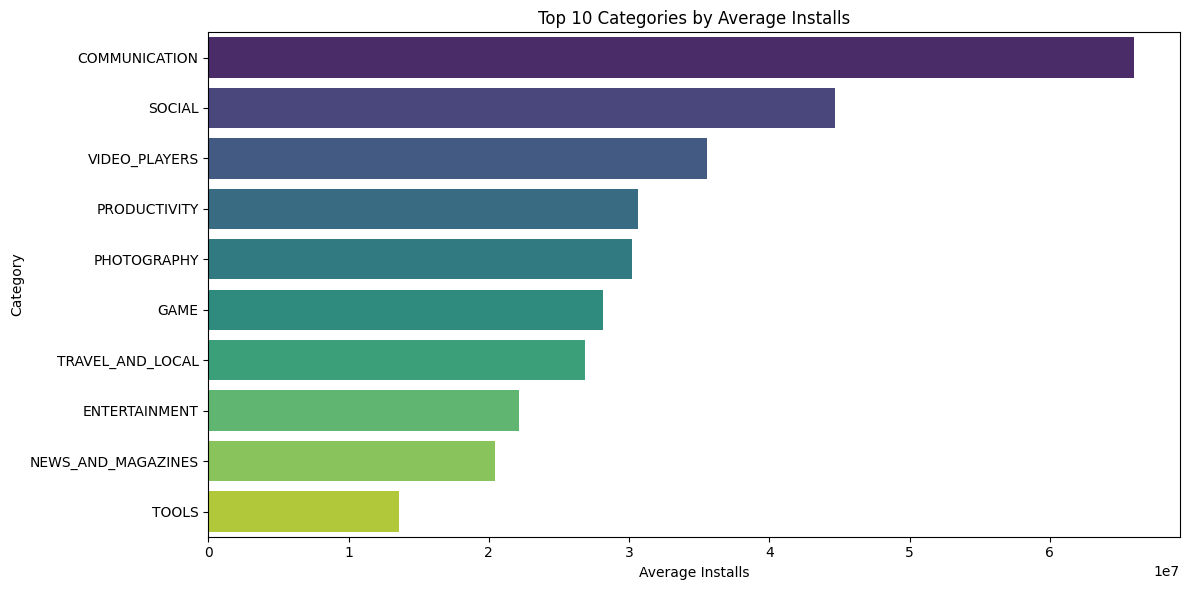

In [16]:
# Analysis Code Here - if needed
#Question 1 — Which app categories have the highest average installs?
category_installs = df_clean.groupBy("Category") \
    .agg(F.avg("Installs").alias("Avg_Installs")) \
    .orderBy("Avg_Installs", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(data=category_installs, x="Avg_Installs", y="Category", palette="viridis")
plt.title("Top 10 Categories by Average Installs")
plt.xlabel("Average Installs")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

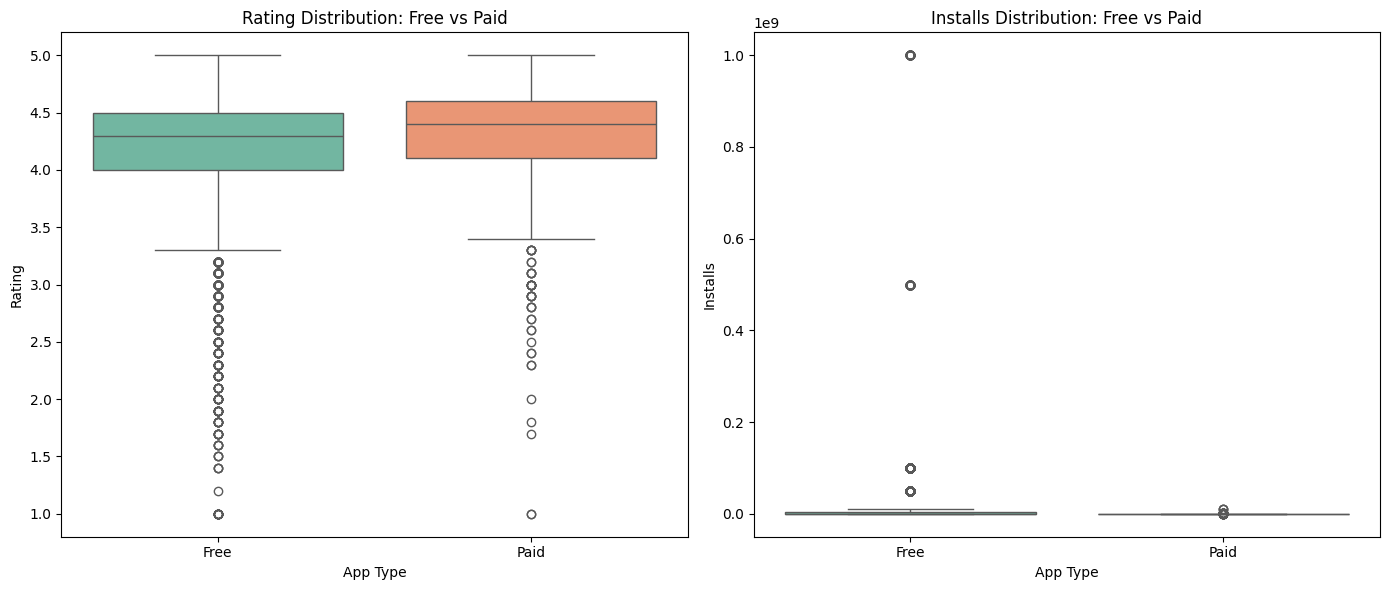

In [17]:
#Question 2 — How does pricing affect ratings and installs?
type_rating = df_clean.select("Type", "Rating", "Installs").dropna().toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=type_rating, x="Type", y="Rating", palette="Set2", ax=axes[0])
axes[0].set_title("Rating Distribution: Free vs Paid")
axes[0].set_xlabel("App Type")
axes[0].set_ylabel("Rating")

sns.boxplot(data=type_rating, x="Type", y="Installs", palette="Set2", ax=axes[1])
axes[1].set_title("Installs Distribution: Free vs Paid")
axes[1].set_xlabel("App Type")
axes[1].set_ylabel("Installs")

plt.tight_layout()
plt.show()

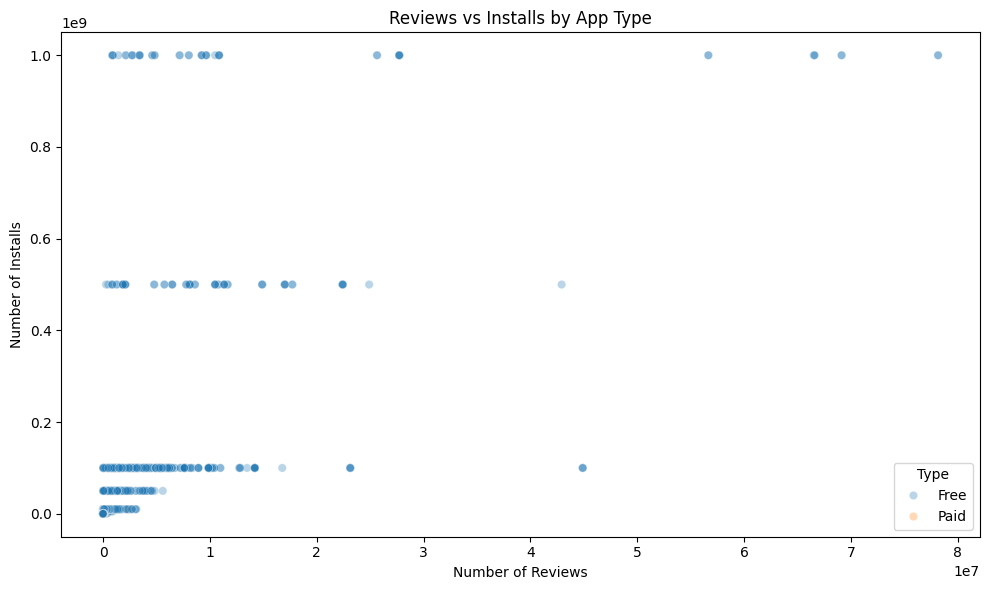

In [18]:
#Question 3 — What is the relationship between reviews and installs?
scatter_df = df_clean.select("Reviews", "Installs", "Type").dropna().toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="Reviews", y="Installs", hue="Type", alpha=0.3)
plt.title("Reviews vs Installs by App Type")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Installs")
plt.tight_layout()
plt.show()

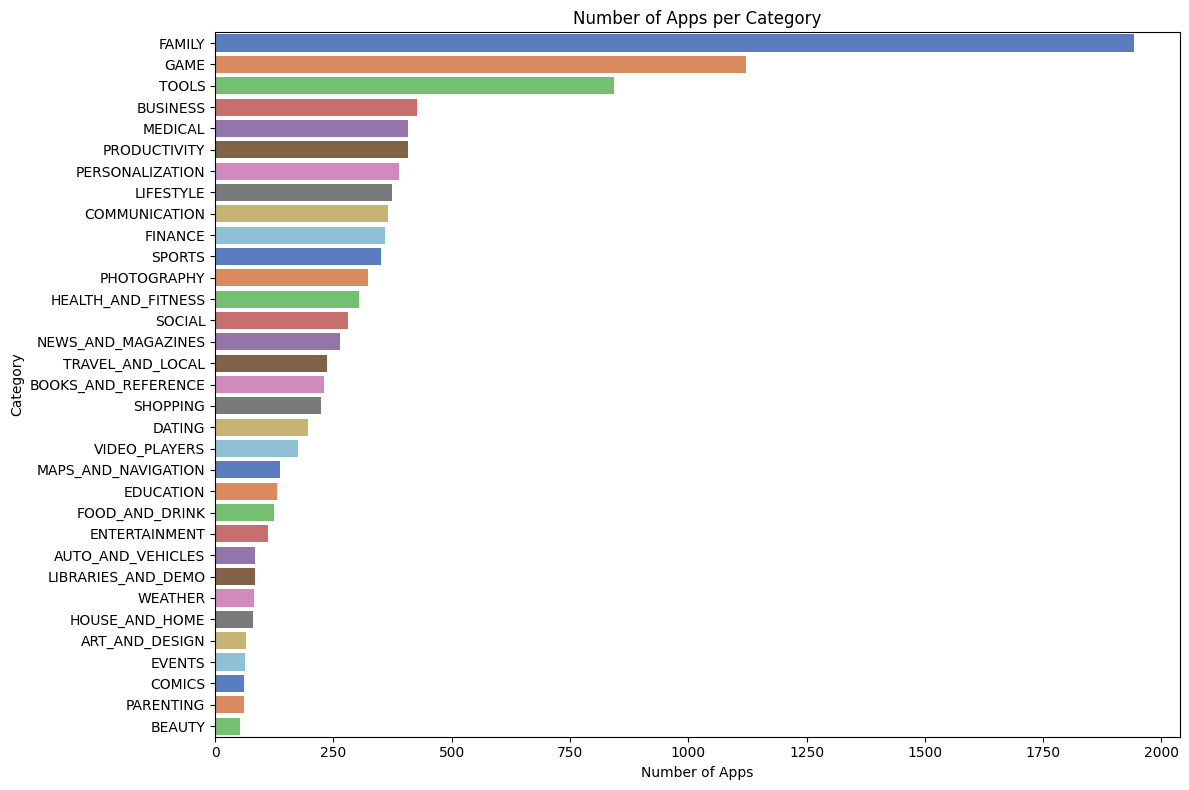

In [19]:
#Question 4 — Which categories are most competitive?
category_count = df_clean.groupBy("Category") \
    .count() \
    .orderBy("count", ascending=False) \
    .toPandas()

plt.figure(figsize=(12, 8))
sns.barplot(data=category_count, x="count", y="Category", palette="muted")
plt.title("Number of Apps per Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

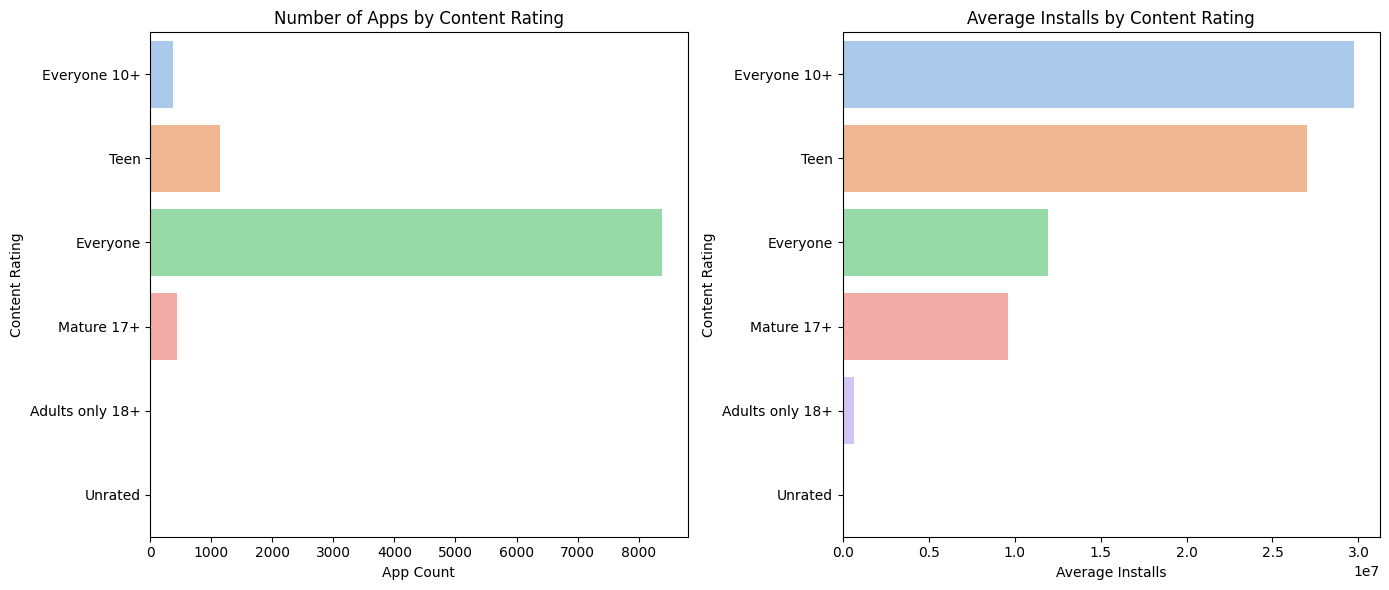

In [20]:
#Question 5 — What content ratings dominate successful apps?
content_installs = df_clean.groupBy("Content Rating") \
    .agg(
        F.count("App").alias("App_Count"),
        F.avg("Installs").alias("Avg_Installs"),
        F.avg("Rating").alias("Avg_Rating")
    ) \
    .orderBy("Avg_Installs", ascending=False) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=content_installs, x="App_Count", y="Content Rating", palette="pastel", ax=axes[0])
axes[0].set_title("Number of Apps by Content Rating")
axes[0].set_xlabel("App Count")
axes[0].set_ylabel("Content Rating")

sns.barplot(data=content_installs, x="Avg_Installs", y="Content Rating", palette="pastel", ax=axes[1])
axes[1].set_title("Average Installs by Content Rating")
axes[1].set_xlabel("Average Installs")
axes[1].set_ylabel("Content Rating")

plt.tight_layout()
plt.show()

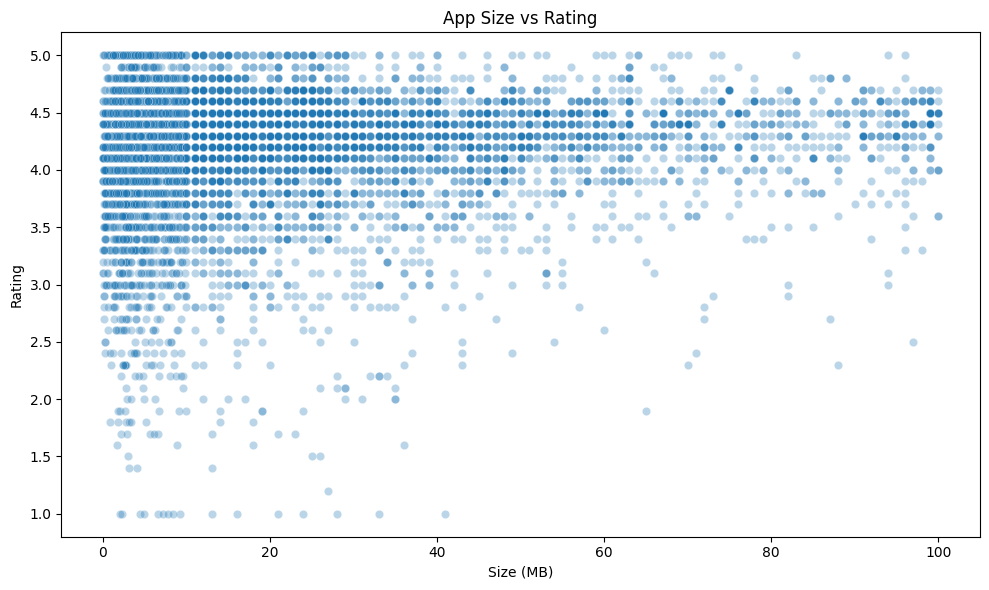

In [21]:
#Question 6 — Is there a relationship between app size and rating?
size_rating = df_clean.select("Size_MB", "Rating", "Category").dropna().toPandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=size_rating, x="Size_MB", y="Rating", alpha=0.3)
plt.title("App Size vs Rating")
plt.xlabel("Size (MB)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

#### Observation: Category Install Leaders
Communication and Social apps dominate average installs by a significant margin, with 
Communication averaging over 65 million installs per app. This is largely driven by 
mega-apps like WhatsApp and Gmail skewing the average upward. For the startup, entering 
Communication or Social is inadvisable — these markets are dominated by a handful of 
entrenched players. Mid-tier categories like Photography, Productivity, and Game offer 
more realistic entry points with strong install potential.

#### Observation: Pricing Strategy
Paid apps show a marginally higher median rating than free apps, suggesting users who 
pay for an app may be more satisfied or more selective. However, free apps dramatically 
outperform paid apps in installs — the installs boxplot shows free apps reaching up to 
1 billion installs while paid apps remain near zero by comparison. For a startup entering 
the market, launching as a free app is strongly supported by the data as the primary 
strategy for gaining initial traction and user base.

#### Observation: Reviews and Installs Correlation
There is a clear positive relationship between reviews and installs — apps with more 
installs tend to accumulate more reviews. The majority of paid apps cluster near zero 
on both axes, reinforcing the install gap seen in Chart 2. The handful of extreme 
outliers in the top right represent dominant free apps with massive user bases. For a 
new startup, this suggests that driving early installs is critical — more users means 
more reviews, which in turn improves visibility on the Play Store.

#### Observation: Market Competition by Category
FAMILY (1,972 apps) and GAME (1,144 apps) are by far the most crowded categories, 
making them highly competitive markets for a new entrant. Categories like BEAUTY, 
PARENTING, COMICS, and EVENTS have fewer than 100 apps each, representing potentially 
underserved niches. The startup should weigh install potential (Chart 1) against 
competition level (this chart) when deciding which category to enter — a category 
with moderate installs and low competition may be more accessible than a high-install, 
saturated one.

#### Observation: Content Rating and Market Reach
"Everyone" rated apps dominate in sheer volume with over 8,500 apps, making it the 
most competitive content segment. However, "Everyone 10+" and "Teen" rated apps 
actually achieve higher average installs despite having far fewer apps — suggesting 
these segments are underserved relative to their demand. For the startup, targeting 
a "Teen" or "Everyone 10+" content rating could provide access to a large install 
base with less direct competition than the "Everyone" segment.

#### Observation: App Size and User Rating
There is no strong linear relationship between app size and rating — high ratings 
appear across the full size spectrum from under 1MB to over 100MB. However, the 
density of high ratings is notably concentrated in the 0-40MB range, suggesting 
that smaller, lighter apps are not penalized by users and may actually be preferred. 
For the startup, this is encouraging — a well-built lightweight app can achieve 
strong ratings without requiring large download sizes, which is particularly 
important for users in markets with limited storage or data plans.

### Dashboard Overview

| Page | Title | Charts Included | Key Question Answered |
|------|-------|----------------|----------------------|
| 1 | Market Overview | Avg Installs by Category (Bar), Category Competition (Treemap) | Which categories should the startup target? |
| 2 | Pricing & Engagement | Avg Rating by Type (Bar), Avg Installs by Type (Bar), Reviews vs Installs (Scatter) | Should the startup launch free or paid? |
| 3 | App Characteristics | Content Rating Volume vs Installs (Dual Bar), App Size vs Rating (Scatter) | What kind of app should the startup build? |

### Interactivity Implemented
- **Top N Parameter** — Page 1 slider controls how many categories display (5–33)
- **Category Filter** — Page 1 filter applies across both charts
- **App Type Filter** — Page 2 radio buttons filter all charts by Free/Paid
- **Content Rating Filter** — Page 3 checkbox filter applies across both charts
- **Highlight Actions** — Hovering/selecting highlights related marks across charts on the same page
- **Navigation Buttons** — Each page has buttons to move between dashboards

### Link to Published Dashboard
[Google Play Store Market Analysis Dashboard](https://public.tableau.com/app/profile/miriam.kilonzo/viz/GooglePlayStoreMarketAnalysis_17807497458760/Page1MarketOverview?publish=yes)

### Design Decisions
- **Consistent color language** — Teal represents Free apps and high-install 
categories throughout all three pages. Gold represents Paid apps. This means 
color carries meaning across the entire dashboard, not just within individual charts.
- **Chart type rationale** — Bar charts are used for category comparisons, scatter plots 
for relationship/correlation questions, and the treemap for showing proportional competition 
— each chart type was chosen specifically because it best represents the structure of that 
data.
- **Trend lines on scatter plots** — Added to make the correlation pattern explicit for 
a non-technical stakeholder audience who may not interpret scatter plots intuitively.
- **Fixed 1200x800 layout** — Chosen for consistent desktop viewing on Tableau Public.

## Conclusion
This analysis of over 10,000 Google Play Store apps reveals several clear and actionable 
trends for a startup preparing to enter the Android market. Free apps dramatically 
outperform paid apps in install volume, making a free-to-download model the strongly 
supported launch strategy for maximizing initial reach. Category selection is critical: 
while Communication and Social categories show the highest average installs, they are 
dominated by a small number of entrenched mega-apps — mid-tier categories like 
Photography and Productivity offer a more realistic competitive entry point. The data 
also shows that targeting a Teen or Everyone 10+ content rating may provide access to 
a large install base with less direct competition than the saturated Everyone segment. 
Finally, app size does not significantly impact user ratings, meaning a well-executed 
lightweight app is not at a disadvantage — an encouraging signal for a startup with 
limited initial resources.

All findings are based on a historical snapshot of Play Store data and should be 
treated as directional trends rather than definitive market guarantees. Future analysis 
could extend this work by incorporating time-series trends, sentiment analysis of 
user reviews, or monetization data to further refine the startup's go-to-market strategy.

## Technical Documentation

### Tools and Libraries
| Tool | Purpose |
|------|---------|
| PySpark | Primary data loading, EDA, and cleaning |
| Pandas |  Bridge for converting Spark DataFrames to plotting format |
| Matplotlib / Seaborn | In-notebook visualizations |
| Tableau Public | Interactive multi-page dashboard |

### PySpark vs Pandas Decision Rationale
PySpark was chosen as the primary processing engine to practice distributed computing 
patterns appropriate for large datasets. Pandas was used only at the visualization 
stage (`toPandas()`) since Matplotlib and Seaborn require in-memory DataFrames. This 
reflects the real-world pattern of using Spark for heavy transformation and Pandas 
only for final, small aggregated outputs.

### Key Cleaning Decisions
- **Duplicates** dropped before any transformation to avoid compounding errors.
- **Corrupt Type rows** (`102248`, `2509`, `NaN`) removed — values appeared to be row-shifted data and could not be reliably corrected.
- **Rating column** cast safely using `rlike` to catch non-numeric strings (`NaN`, `navigation`) before casting, converting them to null rather than dropping the entire row.
- **Installs** stripped of `+` and `,` characters via `regexp_replace` before casting to `LongType`. Values represent minimum thresholds, not exact counts.
- **Size** standardized to MB by dividing `k`-suffix values by 1024. `Varies with device` entries treated as null.
- **Last Updated** parsed from string to `DateType` for potential Tableau time-series use.

### AI Assistance Log
In line with the lab requirement to utilize generative AI as a productivity tool, 
Claude (Anthropic) was consulted at the following points:

| Phase | What AI Was Asked | How Output Was Used |
|-------|-------------------|---------------------|
| Data Prep | Regex pattern for stripping `+` and `,` from Installs | Reviewed and applied directly after testing on sample rows |
| Data Prep | `rlike` approach for safe Rating casting | Adopted after verifying it correctly caught `NaN` and `navigation` values |
| Data Analysis | Subplot layout for Free vs Paid comparison | Used as a starting template, axis labels and palette customized manually |
| Business Questions | Initial brainstorm of analytical questions | Used as a starting list, refined and rephrased to match available columns |

All AI-generated suggestions were verified against actual data outputs and tested 
before inclusion. No AI-generated code was included without review and validation.

### Assumptions and Limitations
- Install values are minimum thresholds (bracket notation), not exact counts.
- Rating nulls (~1,464 rows) and Size_MB nulls (~1,524 rows) are retained in the cleaned dataset; analyses involving these columns exclude null rows via `dropna()`.
- The dataset represents a historical snapshot and does not reflect current Play Store conditions.
- `Current Ver` and `Android Ver` are retained in the cleaned CSV but excluded from analysis.